In [1]:
import pandas as pd

In [5]:
df = pd.read_excel('input_data_2.xlsx')
df

,id,time,Location,Sector_Name,PC,SIZE,Sector_name_Industrials,Sector_name_BasicMaterials,Sector_name_ConsumerCyclicals,Sector_name_RealEstate,...,ROA,ROE,ROS,LEV,NWC,Debt_to_asset,debt_to_equity,EPS,Historic_PE,M_B
0,CHP.HM,2015,2,8,1,12.512587,0,0,0,0,...,0.100852,0.201896,0.450153,0.500476,0.050922,0.50,1.00,1450.62,5.145384,0.974282
1,CHP.HM,2016,2,8,1,12.489081,0,0,0,0,...,0.083591,0.154341,0.396766,0.458401,0.059043,0.46,0.85,2130.66,5.061110,1.030609
2,CHP.HM,2017,2,8,1,12.492136,0,0,0,0,...,0.132130,0.218391,0.476837,0.394984,0.124748,0.39,0.65,1672.38,7.006351,1.255330
3,CHP.HM,2018,2,8,1,12.454687,0,0,0,0,...,0.033659,0.054457,0.204018,0.381923,0.046700,0.38,0.62,2792.99,5.925863,1.203708
4,CHP.HM,2019,2,8,1,12.557708,0,0,0,0,...,0.059821,0.122463,0.302795,0.511516,-0.024564,0.51,1.05,652.71,23.267172,1.229032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3523,IJC.HM,2016,3,4,1,12.960694,0,0,0,1,...,0.000693,0.002134,0.003214,0.675056,0.435078,0.68,2.08,305.90,5.486932,0.241917
3524,IJC.HM,2017,3,4,1,12.904811,0,0,0,1,...,0.001209,0.005844,0.009996,0.793166,0.275049,0.79,3.83,356.73,6.038012,0.644179
3525,IJC.HM,2018,3,4,1,12.910528,0,0,0,1,...,0.000973,0.004560,0.006357,0.786598,0.101288,0.79,3.69,951.71,6.334220,0.475932
3526,IJC.HM,2019,3,4,1,12.879341,0,0,0,1,...,0.001084,0.004427,0.005130,0.755238,0.101293,0.76,3.09,1317.52,3.944949,1.023855


In [12]:
# === GMM clustering for:
# ['SIZE','Location','Sector_Name','Foreign ownership',
#  'Location_HN','Location_TPTW','Location_Tinhthanhkhac',
#  'Age','ROA','ROE','ROS','LEV','NWC','Debt_to_asset',
#  'debt_to_equity','Historic_PE','M_B']

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.pipeline import Pipeline

# 0) Feature lists
FEATURES = [
    'SIZE','Location','Sector_Name','Foreign ownership',
    'Location_HN','Location_TPTW','Location_Tinhthanhkhac',
    'Age','ROA','ROE','ROS','LEV','NWC','Debt_to_asset',
    'debt_to_equity','Historic_PE','M_B'
]

CAT_COLS = ['Location','Sector_Name']                 # to be one-hot encoded
NUM_COLS = [c for c in FEATURES if c not in CAT_COLS] # keep your existing dummies and numeric vars

# 1) Prepare design matrix with proper preprocessing
def prepare_matrix(df):
    # Check columns exist
    missing = [c for c in FEATURES if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Cast numeric columns; non-numeric becomes NaN and will be imputed
    df_num = df[NUM_COLS].apply(pd.to_numeric, errors="coerce")

    # Preprocess blocks
    num_pipe = Pipeline(steps=[
        ("imp", SimpleImputer(strategy="median")),
        ("scl", RobustScaler(quantile_range=(25.0, 75.0)))
    ])
    cat_pipe = Pipeline(steps=[
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, NUM_COLS),
            ("cat", cat_pipe, CAT_COLS)
        ],
        remainder="drop"
    )

    X = pre.fit_transform(pd.concat([df_num, df[CAT_COLS]], axis=1))

    # Capture feature names for later diagnostics
    ohe = pre.named_transformers_["cat"].named_steps["ohe"]
    cat_feature_names = ohe.get_feature_names_out(CAT_COLS).tolist()
    feature_names = NUM_COLS + cat_feature_names

    return X, pre, feature_names

# 2) Fit GMM for a given K and compute metrics
def fit_gmm_metrics(X, k, random_state=42, n_init=20, max_iter=500, reg_covar=1e-6):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        reg_covar=reg_covar,
        init_params="kmeans",
        n_init=n_init,
        max_iter=max_iter,
        random_state=random_state
    ).fit(X)

    labels = gmm.predict(X)
    proba  = gmm.predict_proba(X)
    conf   = proba.max(axis=1)

    # Internal validity metrics
    sil = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else np.nan
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)

    # Likelihood criteria
    bic = gmm.bic(X)
    aic = gmm.aic(X)

    # Membership entropy
    eps = 1e-12
    entropy = -(proba * np.log(proba + eps)).sum(axis=1).mean()

    counts = np.bincount(labels, minlength=k)
    min_share = counts.min() / counts.sum()

    return {
        "k": k,
        "model": gmm,
        "labels": labels,
        "proba": proba,
        "bic": bic,
        "aic": aic,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "mean_entropy": entropy,
        "median_confidence": float(np.median(conf)),
        "cluster_sizes": counts.tolist(),
        "min_cluster_share": float(min_share),
    }

# 3) Search K = 3..10, recommend by BIC with a small sanity screen
def choose_k_and_fit(df, k_range=range(3, 11), min_share_threshold=0.03, min_silhouette=0.02, seed=42):
    X, pre, feat_names = prepare_matrix(df)
    rng = np.random.RandomState(seed)
    rows = []

    for k in k_range:
        res = fit_gmm_metrics(
            X, k,
            random_state=int(rng.randint(0, 1_000_000)),
            n_init=20, max_iter=500, reg_covar=1e-6
        )
        rows.append(res)

    # Summaries table
    results = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ("model","labels","proba")}
        for r in rows
    ]).sort_values("k")

    # Candidate screen
    candidates = results[
        (results["min_cluster_share"] >= min_share_threshold) &
        (results["silhouette"].fillna(-1) >= min_silhouette)
    ]

    if len(candidates) > 0:
        best_k = int(candidates.sort_values("bic").iloc[0]["k"])
    else:
        best_k = int(results.sort_values("bic").iloc[0]["k"])

    # Recover fitted model and predictions
    by_k = {r["k"]: r for r in rows}
    best = by_k[best_k]
    gmm  = best["model"]
    labels = best["labels"]
    proba  = best["proba"]

    # Output dataframe aligned to original index
    out = pd.DataFrame({
        "cluster": labels,
        "cluster_probability": proba.max(axis=1)
    }, index=df.index)

    return best_k, results, out, gmm, pre, feat_names

# 4) Optional cluster profile: numeric medians and categorical distributions
def cluster_profiles(df, out):
    # Numeric medians (original scale)
    num_meds = (
        df[NUM_COLS].apply(pd.to_numeric, errors="coerce")
          .join(out["cluster"])
          .groupby("cluster")[NUM_COLS]
          .median()
          .sort_index()
    )

    # Categorical distributions
    loc_dist = pd.crosstab(out["cluster"], df["Location"], normalize="index").round(3)
    sec_dist = pd.crosstab(out["cluster"], df["Sector_Name"], normalize="index").round(3)

    return num_meds, loc_dist, sec_dist



In [13]:
# ======================
# Run
# ======================
best_k, k_results, clustering, gmm, preprocess, feature_names = choose_k_and_fit(
    df,
    k_range=range(3, 11),
    min_share_threshold=0.03,
    min_silhouette=0.02,
    seed=42
)


print("Recommended K:", best_k)
print("\nK comparison:")
print(k_results[["k","bic","aic","silhouette","davies_bouldin","calinski_harabasz","mean_entropy","median_confidence","min_cluster_share","cluster_sizes"]].to_string(index=False))

Recommended K: 8

K comparison:
 k            bic            aic  silhouette  davies_bouldin  calinski_harabasz  mean_entropy  median_confidence  min_cluster_share                                cluster_sizes
 3 -299914.791784 -308513.661850    0.002295        7.050207        1328.710209 -1.000089e-12                1.0           0.004252                             [1504, 15, 2009]
 4 -340231.945569 -351699.161818   -0.060031        3.806846        1115.242404  1.859952e-03                1.0           0.003401                        [400, 1208, 12, 1908]
 5 -372545.228096 -386880.790529   -0.077931        3.380762        1120.159219  1.116127e-03                1.0           0.003118                   [469, 11, 1359, 168, 1521]
 6 -366734.380487 -383938.289104   -0.189787        2.318178         717.361536  1.092655e-02                1.0           0.001701                 [659, 12, 233, 686, 1932, 6]
 7 -373976.999463 -394049.254264   -0.188138        2.269331         711.943824  9.

In [14]:
print("\nPreview of assignments:")
print(clustering.head())


Preview of assignments:
   cluster  cluster_probability
0        0                  1.0
1        0                  1.0
2        0                  1.0
3        0                  1.0
4        0                  1.0


In [15]:
num_profile, loc_profile, sec_profile = cluster_profiles(df, clustering)
print("\nNumeric medians by cluster:\n", num_profile)
print("\nLocation distribution by cluster (row shares):\n", loc_profile)
print("\nSector distribution by cluster (row shares):\n", sec_profile)


Numeric medians by cluster:
               SIZE  Foreign ownership  Location_HN  Location_TPTW  \
cluster                                                             
0        12.024976            4.22635          0.0            0.0   
1        11.217537            1.14810          0.0            0.0   
2        11.122133            0.57565          0.0            0.0   
3        11.543951            0.81500          0.0            0.0   
4        11.990422            3.12000          0.0            0.0   
5        11.755363            2.96000          0.0            0.0   
6        10.303616           15.97500          1.0            0.0   
7        11.760691            3.15890          0.0            0.0   

         Location_Tinhthanhkhac   Age       ROA        ROE         ROS  \
cluster                                                                  
0                           0.0  19.0  0.021476   0.044163    0.021725   
1                           1.0  17.0  3.516804   6.77129

In [ ]:
# ======================
# Apply to new data later
# ======================
def apply_gmm_to_new(new_df, preprocess, gmm):
    # Recreate X with the same preprocess
    # Ensure numeric casting for numeric cols
    new_df_num = new_df[NUM_COLS].apply(pd.to_numeric, errors="coerce")
    X_new = preprocess.transform(pd.concat([new_df_num, new_df[CAT_COLS]], axis=1))
    labels = gmm.predict(X_new)
    proba  = gmm.predict_proba(X_new).max(axis=1)
    return pd.DataFrame({"cluster": labels, "cluster_probability": proba}, index=new_df.index)

# Example:
# new_assignments = apply_gmm_to_new(df_next, preprocess, gmm)


In [16]:
# === Cluster counts for K = 3..10 using GMM on your feature set ===
# Features:
# ['SIZE','Location','Sector_Name','Foreign ownership',
#  'Location_HN','Location_TPTW','Location_Tinhthanhkhac',
#  'Age','ROA','ROE','ROS','LEV','NWC','Debt_to_asset',
#  'debt_to_equity','Historic_PE','M_B']

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

FEATURES = [
    'SIZE','Location','Sector_Name','Foreign ownership',
    'Location_HN','Location_TPTW','Location_Tinhthanhkhac',
    'Age','ROA','ROE','ROS','LEV','NWC','Debt_to_asset',
    'debt_to_equity','Historic_PE','M_B'
]
CAT_COLS = ['Location','Sector_Name']
NUM_COLS = [c for c in FEATURES if c not in CAT_COLS]

def _make_ohe():
    # Works on both old and new scikit-learn
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def prepare_matrix(df):
    missing = [c for c in FEATURES if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df_num = df[NUM_COLS].apply(pd.to_numeric, errors="coerce")

    num_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scl", RobustScaler(quantile_range=(25.0, 75.0)))
    ])
    cat_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", _make_ohe())
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, NUM_COLS),
            ("cat", cat_pipe, CAT_COLS)
        ],
        remainder="drop"
    )

    X = pre.fit_transform(pd.concat([df_num, df[CAT_COLS]], axis=1))
    return X, pre

def cluster_counts_across_k(df, k_range=range(3, 11), seed=42):
    X, pre = prepare_matrix(df)
    rng = np.random.RandomState(seed)

    rows = []
    for k in k_range:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            reg_covar=1e-6,
            init_params="kmeans",
            n_init=20,
            max_iter=500,
            random_state=int(rng.randint(0, 1_000_000))
        ).fit(X)

        labels = gmm.predict(X)
        counts = np.bincount(labels, minlength=k)
        shares = counts / counts.sum()

        for c in range(k):
            rows.append({
                "k": k,
                "cluster": c,
                "count": int(counts[c]),
                "share": float(shares[c])
            })

    long_tbl = pd.DataFrame(rows).sort_values(["k","cluster"]).reset_index(drop=True)
    wide_counts = long_tbl.pivot(index="k", columns="cluster", values="count").fillna(0).astype(int)
    wide_counts.columns = [f"cluster_{c}" for c in wide_counts.columns]

    # Also provide a quick summary of imbalance per K
    min_share = long_tbl.groupby("k")["share"].min().rename("min_cluster_share")
    max_share = long_tbl.groupby("k")["share"].max().rename("max_cluster_share")
    summary = pd.concat([min_share, max_share], axis=1)
    return long_tbl, wide_counts, summary

# Run and print
long_counts, wide_counts, balance_summary = cluster_counts_across_k(df, k_range=range(3, 11), seed=42)

print("Counts per cluster (long format):")
print(long_counts.to_string(index=False))

print("\nCounts table by K (wide format):")
print(wide_counts.to_string())

print("\nBalance summary by K:")
print(balance_summary.to_string())

Counts per cluster (long format):
 k  cluster  count    share
 3        0   1504 0.426304
 3        1     15 0.004252
 3        2   2009 0.569444
 4        0    400 0.113379
 4        1   1208 0.342404
 4        2     12 0.003401
 4        3   1908 0.540816
 5        0    469 0.132937
 5        1     11 0.003118
 5        2   1359 0.385204
 5        3    168 0.047619
 5        4   1521 0.431122
 6        0    659 0.186791
 6        1     12 0.003401
 6        2    233 0.066043
 6        3    686 0.194444
 6        4   1932 0.547619
 6        5      6 0.001701
 7        0    129 0.036565
 7        1    213 0.060374
 7        2     10 0.002834
 7        3   1079 0.305839
 7        4    565 0.160147
 7        5     15 0.004252
 7        6   1517 0.429989
 8        0    634 0.179705
 8        1      9 0.002551
 8        2     14 0.003968
 8        3    129 0.036565
 8        4   1428 0.404762
 8        5    897 0.254252
 8        6      1 0.000283
 8        7    416 0.117914
 9        0   

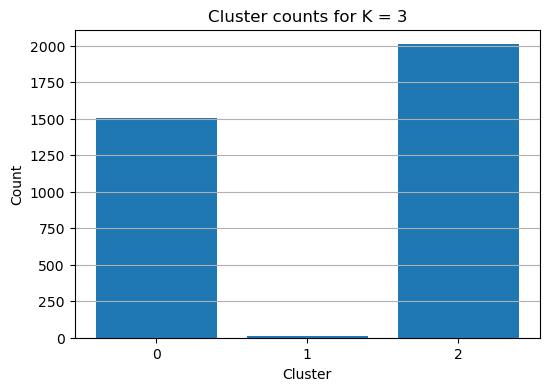

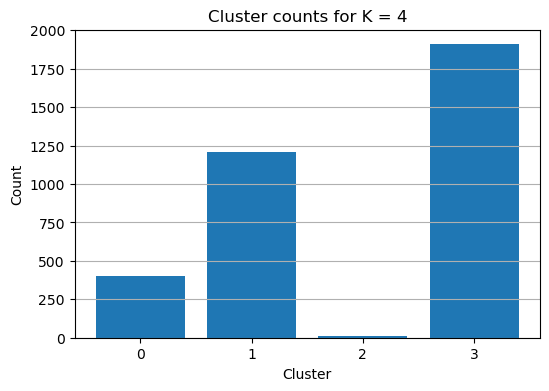

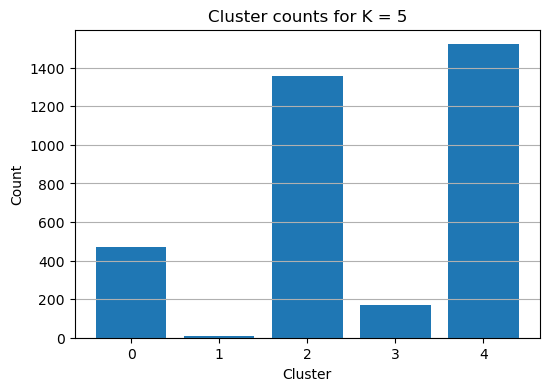

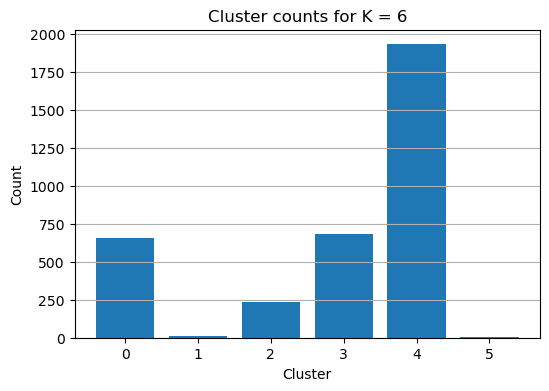

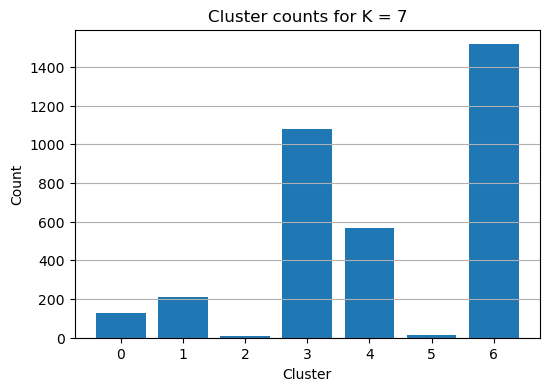

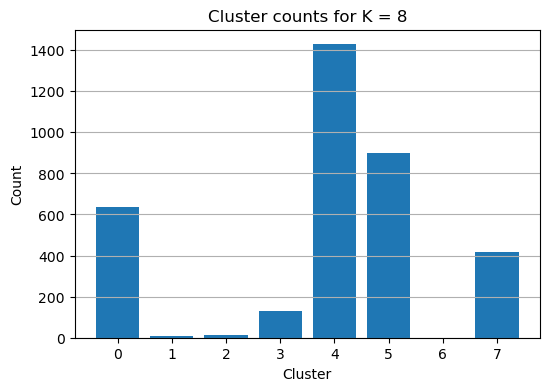

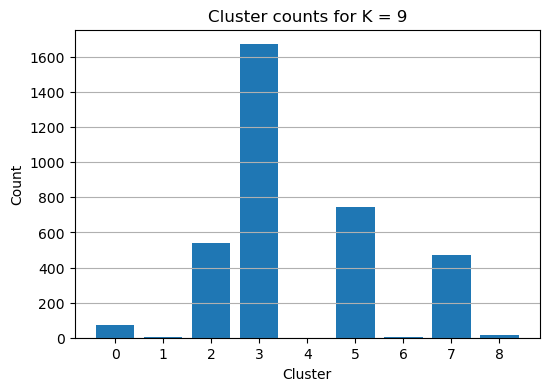

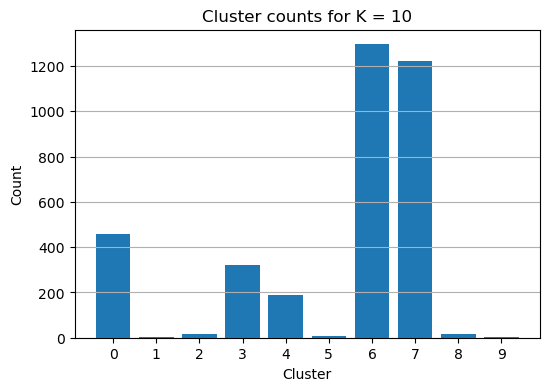

In [17]:

# Optional: bar charts of counts for each K (one figure per K)
def plot_cluster_count_bars(long_counts):
    for k, sub in long_counts.groupby("k"):
        plt.figure(figsize=(6,4))
        plt.bar(sub["cluster"].astype(str), sub["count"].values)
        plt.title(f"Cluster counts for K = {k}")
        plt.xlabel("Cluster")
        plt.ylabel("Count")
        plt.grid(True, axis="y")
        plt.show()

# Example:
plot_cluster_count_bars(long_counts)

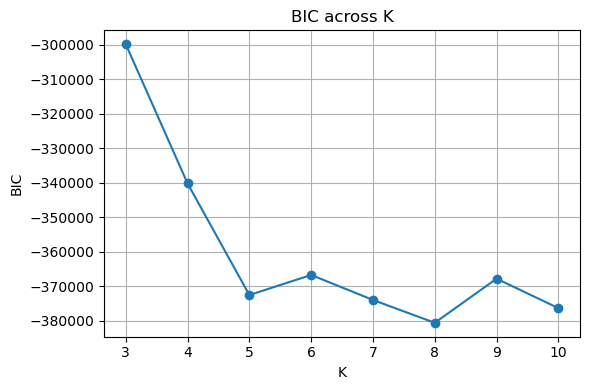

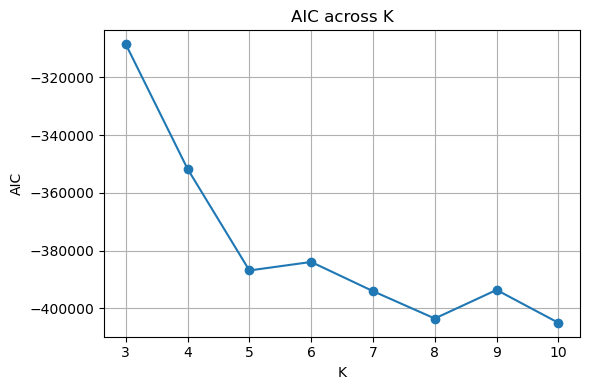

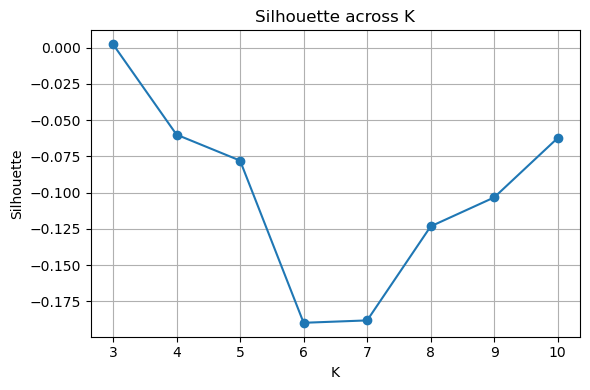

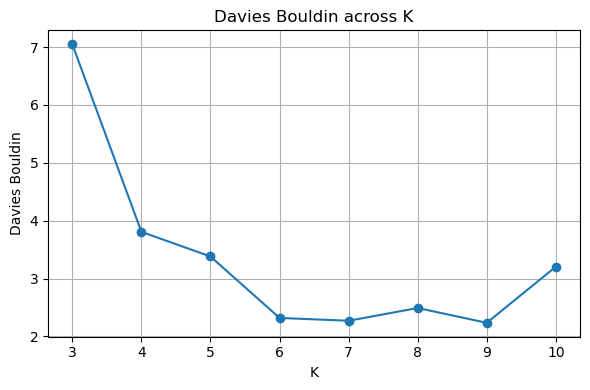

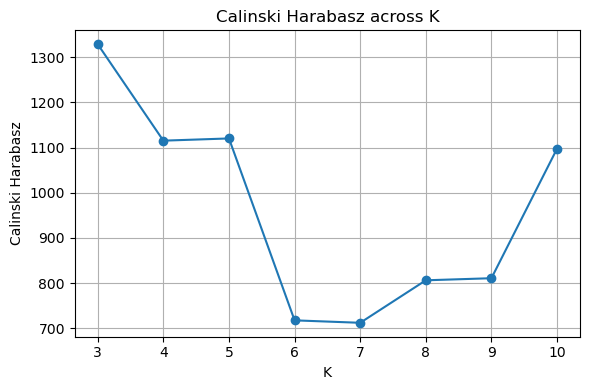

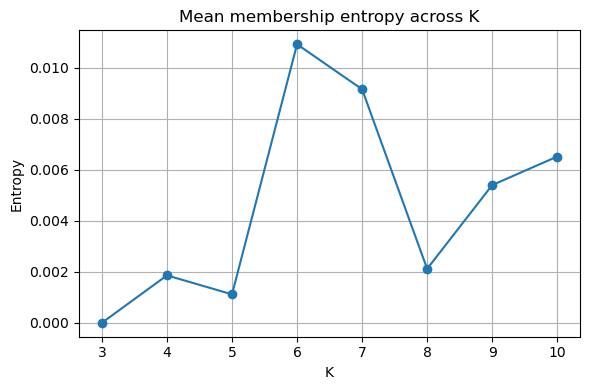

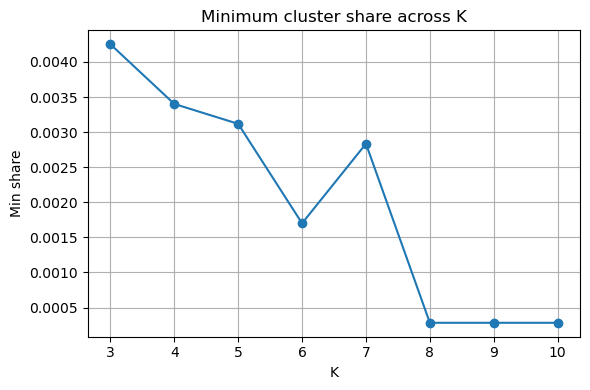

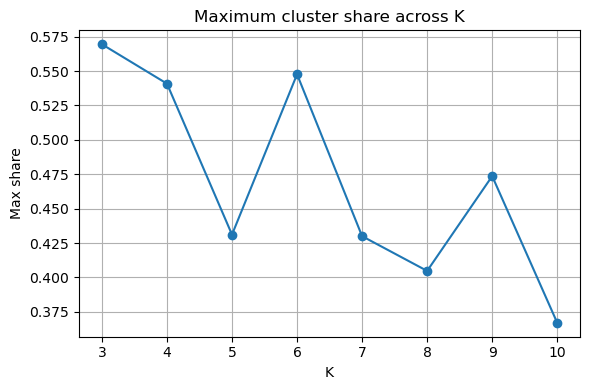

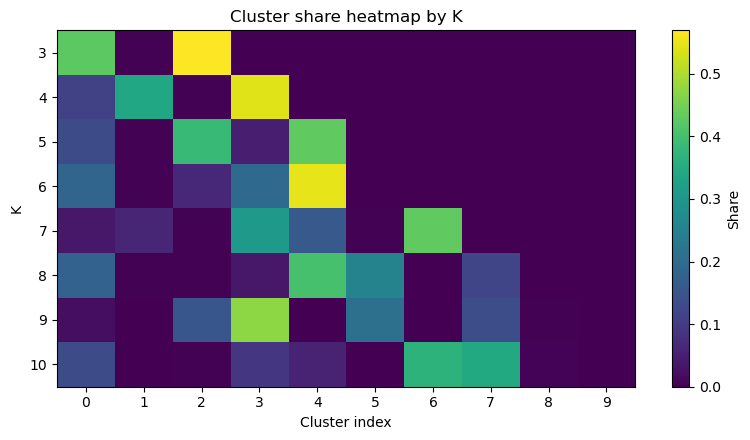

In [18]:
# === Compare GMM results across K (3..10) and plot charts ===
# Columns expected in df:
# ['SIZE','Location','Sector_Name','Foreign ownership',
#  'Location_HN','Location_TPTW','Location_Tinhthanhkhac',
#  'Age','ROA','ROE','ROS','LEV','NWC','Debt_to_asset',
#  'debt_to_equity','Historic_PE','M_B']

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.pipeline import Pipeline

# ----------------------------
# 1) Config
# ----------------------------
FEATURES = [
    'SIZE','Location','Sector_Name','Foreign ownership',
    'Location_HN','Location_TPTW','Location_Tinhthanhkhac',
    'Age','ROA','ROE','ROS','LEV','NWC','Debt_to_asset',
    'debt_to_equity','Historic_PE','M_B'
]
CAT_COLS = ['Location','Sector_Name']
NUM_COLS = [c for c in FEATURES if c not in CAT_COLS]
K_RANGE = range(3, 11)

# ----------------------------
# 2) Preprocess builder
# ----------------------------
def _make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def prepare_matrix(df):
    missing = [c for c in FEATURES if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df_num = df[NUM_COLS].apply(pd.to_numeric, errors="coerce")

    num_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scl", RobustScaler(quantile_range=(25.0, 75.0)))
    ])
    cat_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", _make_ohe())
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, NUM_COLS),
            ("cat", cat_pipe, CAT_COLS),
        ],
        remainder="drop"
    )
    X = pre.fit_transform(pd.concat([df_num, df[CAT_COLS]], axis=1))
    return X, pre

# ----------------------------
# 3) Fit GMM for a given K and compute metrics
# ----------------------------
def fit_gmm_and_metrics(X, k, seed=42):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        reg_covar=1e-6,
        init_params="kmeans",
        n_init=20,
        max_iter=500,
        random_state=seed
    ).fit(X)

    labels = gmm.predict(X)
    proba  = gmm.predict_proba(X)

    counts = np.bincount(labels, minlength=k)
    shares = counts / counts.sum()

    # Internal validity
    sil = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else np.nan
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)

    # Likelihood criteria
    bic = gmm.bic(X)
    aic = gmm.aic(X)

    # Membership entropy
    eps = 1e-12
    mean_entropy = -(proba * np.log(proba + eps)).sum(axis=1).mean()

    return {
        "k": k,
        "gmm": gmm,
        "labels": labels,
        "counts": counts,
        "shares": shares,
        "bic": bic,
        "aic": aic,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "mean_entropy": mean_entropy,
        "min_share": shares.min(),
        "max_share": shares.max(),
    }

# ----------------------------
# 4) Run across K and collect results
# ----------------------------
X, preprocess = prepare_matrix(df)
rng = np.random.RandomState(42)
rows = []

for k in K_RANGE:
    res = fit_gmm_and_metrics(X, k, seed=int(rng.randint(0, 1_000_000)))
    rows.append(res)

# Build summary DataFrame of metrics
metrics_df = pd.DataFrame([{
    "k": r["k"],
    "bic": r["bic"],
    "aic": r["aic"],
    "silhouette": r["silhouette"],
    "davies_bouldin": r["davies_bouldin"],
    "calinski_harabasz": r["calinski_harabasz"],
    "mean_entropy": r["mean_entropy"],
    "min_share": r["min_share"],
    "max_share": r["max_share"]
} for r in rows]).sort_values("k")

# Build a heatmap matrix of cluster shares (rows=K, cols=cluster index 0..maxK-1)
max_k = max(K_RANGE)
share_mat = np.zeros((len(K_RANGE), max_k))
for i, r in enumerate(rows):
    k = r["k"]
    share_mat[i, :k] = r["shares"]
    if k < max_k:
        share_mat[i, k:] = 0.0  # no clusters beyond k

# ----------------------------
# 5) Plot comparison charts
# ----------------------------
def plot_line(x, y, title, ylab):
    plt.figure(figsize=(6,4))
    plt.plot(x, y, marker="o")
    plt.title(title)
    plt.xlabel("K")
    plt.ylabel(ylab)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Metrics vs K
plot_line(metrics_df["k"], metrics_df["bic"], "BIC across K", "BIC")
plot_line(metrics_df["k"], metrics_df["aic"], "AIC across K", "AIC")
plot_line(metrics_df["k"], metrics_df["silhouette"], "Silhouette across K", "Silhouette")
plot_line(metrics_df["k"], metrics_df["davies_bouldin"], "Davies Bouldin across K", "Davies Bouldin")
plot_line(metrics_df["k"], metrics_df["calinski_harabasz"], "Calinski Harabasz across K", "Calinski Harabasz")
plot_line(metrics_df["k"], metrics_df["mean_entropy"], "Mean membership entropy across K", "Entropy")
plot_line(metrics_df["k"], metrics_df["min_share"], "Minimum cluster share across K", "Min share")
plot_line(metrics_df["k"], metrics_df["max_share"], "Maximum cluster share across K", "Max share")

# Heatmap of cluster shares by K
plt.figure(figsize=(8, 4.5))
plt.imshow(share_mat, aspect="auto")
plt.title("Cluster share heatmap by K")
plt.xlabel("Cluster index")
plt.ylabel("K")
plt.xticks(ticks=np.arange(max_k), labels=[str(j) for j in range(max_k)])
plt.yticks(ticks=np.arange(len(K_RANGE)), labels=[str(k) for k in K_RANGE])
plt.colorbar(label="Share")
plt.tight_layout()
plt.show()


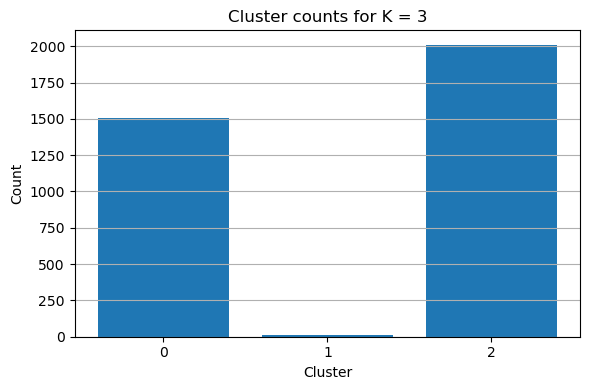

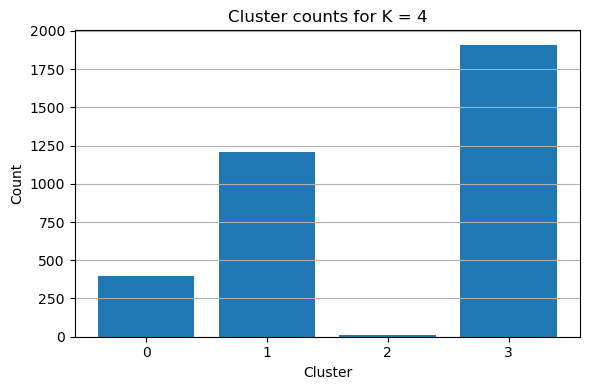

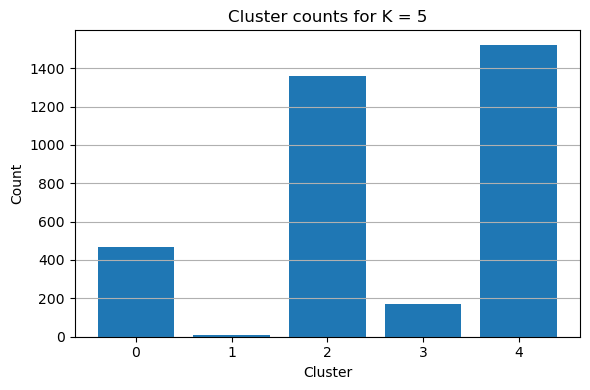

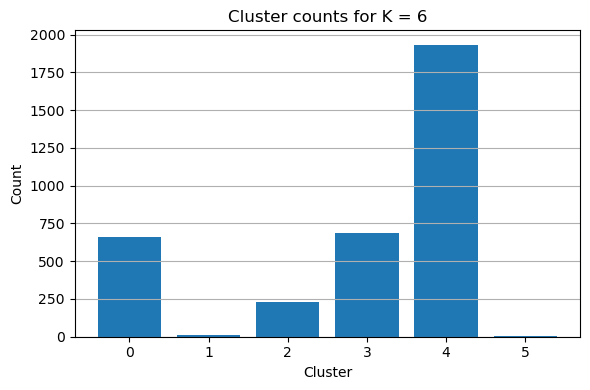

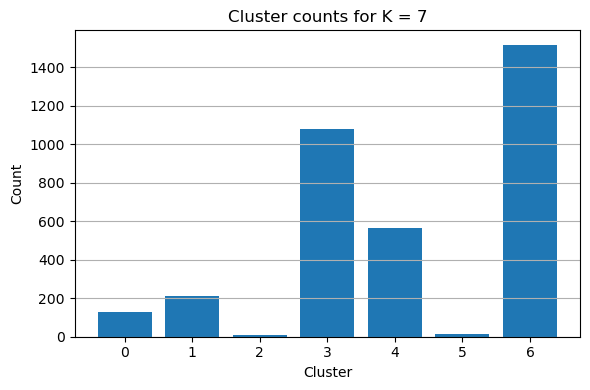

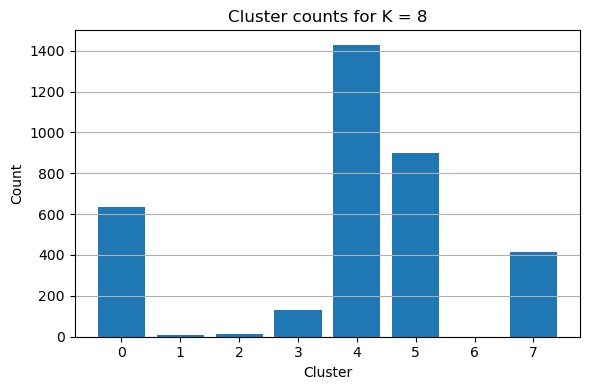

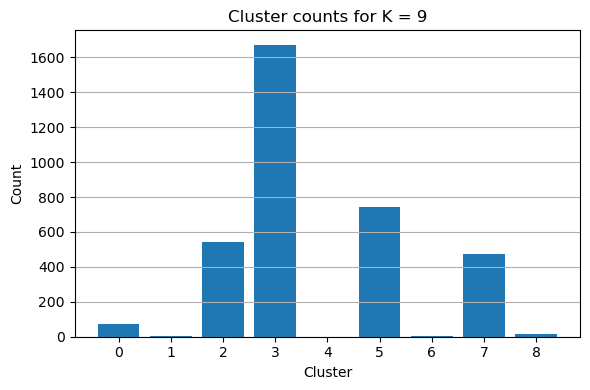

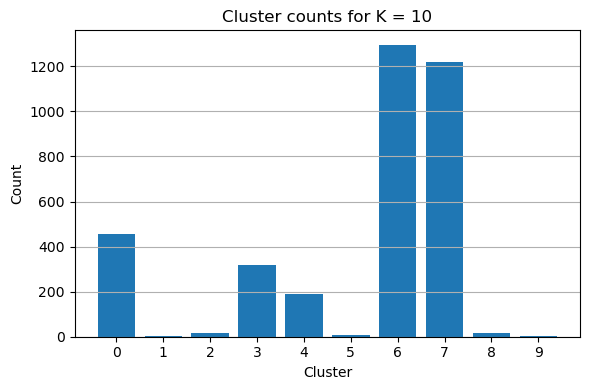

In [19]:

# Optional: stacked bar of cluster counts by K (one figure per K if you prefer)
def plot_counts_per_k(rows):
    for r in rows:
        k = r["k"]
        counts = r["counts"]
        plt.figure(figsize=(6,4))
        plt.bar(np.arange(k).astype(str), counts)
        plt.title(f"Cluster counts for K = {k}")
        plt.xlabel("Cluster")
        plt.ylabel("Count")
        plt.grid(True, axis="y")
        plt.tight_layout()
        plt.show()

# Example:
plot_counts_per_k(rows)

In [20]:
# You can inspect the metrics table too:
print(metrics_df.to_string(index=False))

 k            bic            aic  silhouette  davies_bouldin  calinski_harabasz  mean_entropy  min_share  max_share
 3 -299914.791784 -308513.661850    0.002295        7.050207        1328.710209 -1.000089e-12   0.004252   0.569444
 4 -340231.945569 -351699.161818   -0.060031        3.806846        1115.242404  1.859952e-03   0.003401   0.540816
 5 -372545.228096 -386880.790529   -0.077931        3.380762        1120.159219  1.116127e-03   0.003118   0.431122
 6 -366734.380487 -383938.289104   -0.189787        2.318178         717.361536  1.092655e-02   0.001701   0.547619
 7 -373976.999463 -394049.254264   -0.188138        2.269331         711.943824  9.160310e-03   0.002834   0.429989
 8 -380585.774962 -403526.375947   -0.123281        2.489807         806.045599  2.116759e-03   0.000283   0.404762
 9 -367814.071479 -393623.018648   -0.103308        2.234225         810.648161  5.402068e-03   0.000283   0.473639
10 -376336.031032 -405013.324385   -0.062316        3.203090        1097